# Generate Figure 4

### Load libraries:

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Bring your packages onto the path
import sys, os
sys.path.append(os.path.abspath('..'))

import train
from torch.nn import functional as F
from geomloss import SamplesLoss  # See also ImagesLoss, VolumesLoss

[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc
collect2: error: ld returned 1 exit status

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc
collect2: error: ld returned 1 exit status

OK


### Define useful functions:

In [2]:
def project_A_onto_colspace_B(A, B):
    B_pinv = np.linalg.pinv(B)   # Moore–Penrose pseudoinverse
    A_parallel = B @ B_pinv @ A
    return A_parallel

def get_conditional_mean1(m):
  """Compute the conditional mean E[n | x = m] for a Gaussian mixture model."""
  a_ms = [[-0.87, 0.87], [-0.87, -0.87], [0.87, -0.87], [0.87, 0.87]]
  a_ns = [[-2.31, 2.31], [-2.31, -2.31], [2.31, -2.31], [2.31, 2.31]]
  cov_true = np.array([[0.25, 0, 0, 0], 
      [0, 0.25, 0, 0],
      [0, 0, 0.25, 0],
      [0, 0, 0, 0.25]])

  m = np.asarray(m)
  a_ms = np.asarray(a_ms)
  a_ns = np.asarray(a_ns)

  cov_xx = cov_true[:2, :2]
  cov_yx = cov_true[2:, :2]
  inv_cov_xx = np.linalg.inv(cov_xx)  # compute once

  # Precompute differences (shape: [n, 2])
  diff = a_ms - m

  # Compute Mahalanobis distances efficiently
  md2 = np.einsum('ij,jk,ik->i', diff, inv_cov_xx, diff)
  weights = np.exp(-0.5 * md2)
  weights /= np.sum(weights)  # normalize

  # Compute conditional means for each component
  cond_means = a_ns + (cov_yx @ inv_cov_xx @ diff.T).T  # shape: [n, 1 or d]

  # Weighted sum (conditional mean)
  mean_val = np.sum(weights[:, None] * cond_means, axis=0)
  return mean_val.squeeze()

def get_conditional_mean(SigmaTot, m):
    return SigmaTot[2:, :2] @ np.linalg.inv(SigmaTot[:2, :2]) @ m

### Compute distance across datasets:

In [3]:
data_names = ['quadstable_attractors', 'bistable_attractors', 'limit_cycle', 'ring_attractor']

our_dist_matrix = np.zeros((4, 4))
valente_dist_matrix = np.zeros((4, 4))
valente_dist_matrix_ours = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        data = np.load(f'../data/{data_names[i]}.npz')
        params = torch.load(f"../lint/{data_names[j]}/connector/model_fold_1_seed_1_id_0.pth")
        model = train.ConnectivityDistribution(
            mbd_dim=2,
            n_dim=2,
            time_dim=1,
            hidden_dim=params['args']['hidden_dim'],
        scale=params['args']['scale']
        ).to('cuda')
        model.load_state_dict(params['model_state_dict'])

        Mb_model, N_model = model.sample(1000, sigma=0)
        M_valente = Mb_model[:,:params['args']['latent_dim']].detach().cpu().numpy()
        N_valente = N_model.detach().cpu().numpy()
        N_parallel = project_A_onto_colspace_B(N_valente, M_valente)
        N_parallel_data = project_A_onto_colspace_B(data['N'], data['MBD'])
        
        Sigma = np.zeros((2,2))
        if data_names[i] == 'bistable_attractors':
            # ==== bistable attractors ==== #
            Sigma[0,0] = 1.2
            Sigma[0,1] = 0.8
            Sigma[1,1] = 1.6
        elif data_names[i] == 'limit_cycle':
            # ==== limit cycle ==== #
            Sigma[0,0] = 1.6
            Sigma[1,1] = 1.6
            Sigma[0,1] = -0.8
            Sigma[1,0] = 0.8
        elif data_names[i] == 'ring_attractor':
            # ==== ring attractor ==== #
            Sigma[0,0] = 1.6
            Sigma[1,1] = 1.6
            Sigma[0,1] = 0.

        SigmaTot = np.eye(4)
        SigmaTot[2,2] = 4
        SigmaTot[3,3] = 4
        
        SigmaTot[0,2] = Sigma[0,0]
        SigmaTot[0,3] = Sigma[1,0]
        SigmaTot[1,2] = Sigma[0,1]
        SigmaTot[1,3] = Sigma[1,1]

        SigmaTot[2,0] = SigmaTot[0,2]
        SigmaTot[3,0] = SigmaTot[0,3]
        SigmaTot[2,1] = SigmaTot[1,2]
        SigmaTot[3,1] = SigmaTot[1,3]

        if data_names[i] == 'quadstable_attractors':
            optimal_ns = np.array([get_conditional_mean1(M_valente[i,:]) for i in range(M_valente.shape[0])])
        else:
            optimal_ns = np.array([get_conditional_mean(SigmaTot, M_valente[i,:]) for i in range(M_valente.shape[0])])

        # Create some large point clouds in 3D
        x = torch.tensor(data['MBD'], requires_grad=True).float().cuda()
        y = torch.tensor(M_valente, requires_grad=True).float().cuda() #torch.randn(200000, 3).cuda()

        # Define a Sinkhorn (~Wasserstein) loss between sampled measures
        loss = SamplesLoss(loss="sinkhorn", p=2, blur=.05)
        L = loss(x, y)
        our_dist = L.item() + np.mean((optimal_ns - N_valente)**2)

        Jeff1 = data['MBD'] @ N_parallel_data.T
        Jeff2 = M_valente @ N_parallel.T
        valente_dist = 1 - np.corrcoef(np.sort(Jeff1.flatten()), np.sort(Jeff2.flatten()))[0,1]

        Jeff1_ours = data['MBD'] @ optimal_ns.T
        Jeff2_ours = M_valente @ N_valente.T
        valente_dist_ours = np.mean((Jeff1_ours - Jeff2_ours)**2)

        our_dist_matrix[i, j] = our_dist
        valente_dist_matrix[i, j] = valente_dist
        valente_dist_matrix_ours[i, j] = valente_dist_ours

### Dissimilarity between connectivities using Valente et al., 2022:

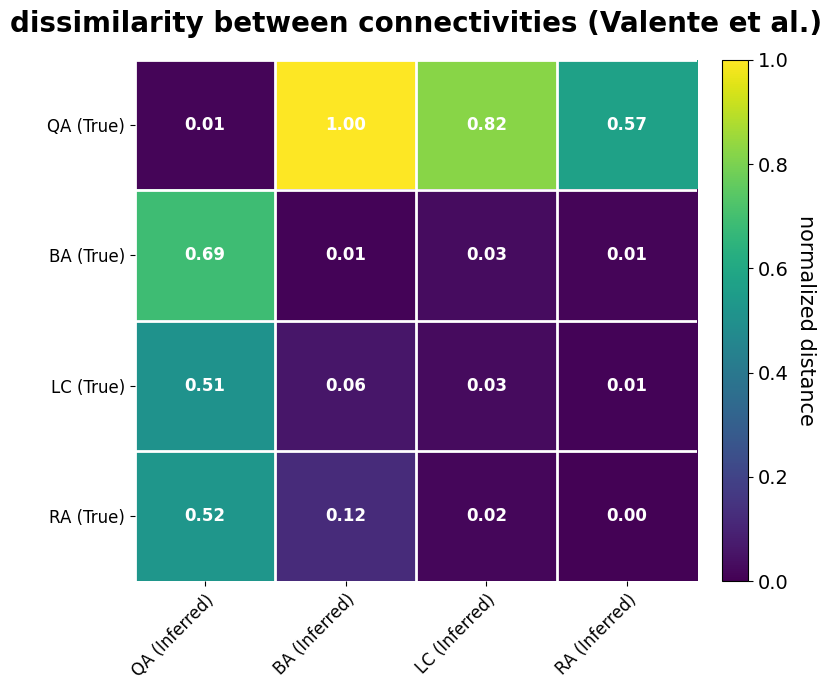

In [4]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 7))

valente_dist_matrix_ = valente_dist_matrix/max(valente_dist_matrix.flatten())
# Create the imshow plot
im = ax.imshow(valente_dist_matrix_, cmap='viridis', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('normalized distance', rotation=270, labelpad=20, fontsize=15)
cbar.ax.tick_params(labelsize=14)

# Set tick positions and labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(['QA (Inferred)', 'BA (Inferred)', 'LC (Inferred)', 'RA (Inferred)'], fontsize=12)
ax.set_yticklabels(['QA (True)', 'BA (True)', 'LC (True)', 'RA (True)'], fontsize=12)

#data_names = ['quadstable_attractors', 'bistable_attractors', 'limit_cycle', 'ring_attractor']

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations showing the values in each cell
for i in range(4):
    for j in range(4):
        text = ax.text(j, i, f'{valente_dist_matrix_[i, j]:.2f}',
                      ha="center", va="center", color="white", fontsize=12, fontweight='bold')

# Add title
ax.set_title('dissimilarity between connectivities (Valente et al.)', fontsize=20, fontweight='bold', pad=20)

# Add grid for better cell separation
ax.set_xticks(np.arange(4) - 0.5, minor=True)
ax.set_yticks(np.arange(4) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", size=0)  # Hide minor tick marks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### Dissimilarity between connectivities using ours:

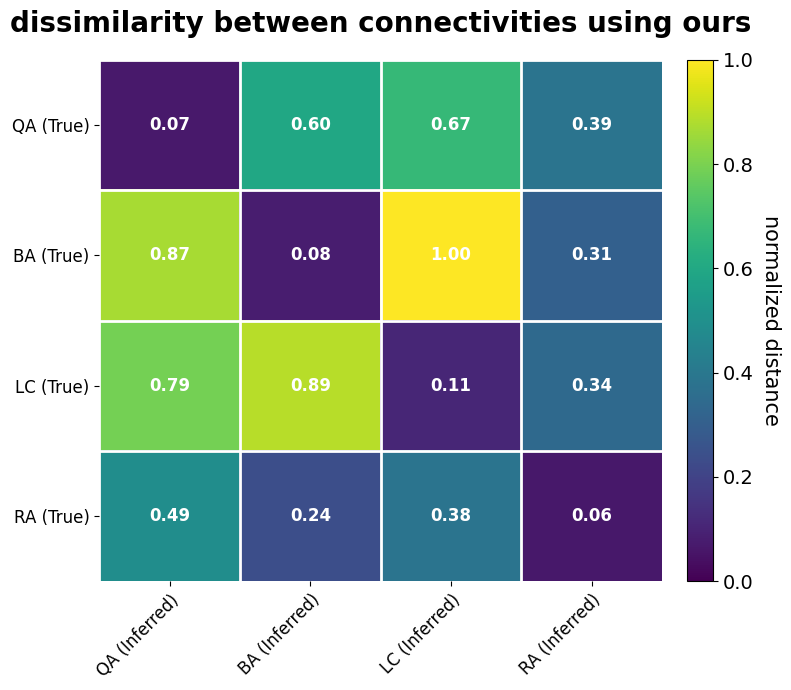

In [5]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 7))

our_dist_matrix_ = our_dist_matrix/max(our_dist_matrix.flatten())
# Create the imshow plot
im = ax.imshow(our_dist_matrix_, cmap='viridis', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('normalized distance', rotation=270, labelpad=20, fontsize=15)
cbar.ax.tick_params(labelsize=14)

# Set tick positions and labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(['QA (Inferred)', 'BA (Inferred)', 'LC (Inferred)', 'RA (Inferred)'], fontsize=12)
ax.set_yticklabels(['QA (True)', 'BA (True)', 'LC (True)', 'RA (True)'], fontsize=12)

#data_names = ['quadstable_attractors', 'bistable_attractors', 'limit_cycle', 'ring_attractor']

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations showing the values in each cell
for i in range(4):
    for j in range(4):
        text = ax.text(j, i, f'{our_dist_matrix_[i, j]:.2f}',
                      ha="center", va="center", color="white", fontsize=12, fontweight='bold')

# Add title
ax.set_title('dissimilarity between connectivities using ours', fontsize=20, fontweight='bold', pad=20)

# Add grid for better cell separation
ax.set_xticks(np.arange(4) - 0.5, minor=True)
ax.set_yticks(np.arange(4) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", size=0)  # Hide minor tick marks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()